In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = "/content/drive/MyDrive/kg_recsys"
os.makedirs(os.path.join(PROJECT_ROOT, "cache"), exist_ok=True)

import subprocess
subprocess.run(["pip", "install", "-q", "transformers", "tqdm"], check=True)

Mounted at /content/drive


CompletedProcess(args=['pip', 'install', '-q', 'transformers', 'tqdm'], returncode=0)

In [2]:
import sys, os, json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from tqdm import tqdm
import torch

SCRIPTS_DIR = os.path.join(PROJECT_ROOT, "scripts")
sys.path.insert(0, SCRIPTS_DIR)
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from data_prep import load_ml100k, load_ml1m, subset_data, train_test_split, GENRE_COLS
from kg_builder import build_adj, load_or_build_kg, BASE_RELS, load_or_build_kg_imdb
from paths import sample_guided_paths, path_is_faithful
from model import (
    build_vocab, is_relation, create_path_dataset, create_model,
    train_model, score_path, generate_topk, enumerate_candidates,
)
from metrics import (
    evaluate_ranking, compute_group_metrics,
    compute_all_ilap_metrics, print_ilap_report,
    demographic_parity, counterfactual_fairness_score,
    print_additional_fairness_report, build_user_gender_map,
    path_diversity_summary, print_path_diversity_report,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [3]:
LAMBDA_PATH_BALANCE = 0.0
PATH_BALANCE_FREE_REPEATS = 2

EVAL_BATCH_SIZE = 2048 if torch.cuda.is_available() else 256
print("Evaluation batch size:", EVAL_BATCH_SIZE)

MAX_PATHS_PER_MOVIE = 5
print("Max paths per movie:", MAX_PATHS_PER_MOVIE)

Evaluation batch size: 2048
Max paths per movie: 5


## 2. Data Loading & Preprocessing

In [4]:
DATASET_NAME = "ML-1M"
DATA_DIR = os.path.join(PROJECT_ROOT, "ml-1m")
LIKE_THRESHOLD = 4
MAX_USERS = 1000
MAX_MOVIES = 1000
BALANCE_GENDER = True

ratings, movies, users = load_ml1m(DATA_DIR)

ratings_sub, movies_sub, users_sub, positive_interactions, user_info = subset_data(
    ratings,
    movies,
    users,
    max_users=MAX_USERS,
    max_movies=MAX_MOVIES,
    like_threshold=LIKE_THRESHOLD,
    balance_gender=BALANCE_GENDER,
)

print("=" * 60)
print(f"{DATASET_NAME} DATASET FOR PEARLM-STYLE COMPARISON")
print("=" * 60)
print(f"Users in subset: {len(users_sub)}")
print(f"Movies in subset: {len(movies_sub)}")
print(f"Ratings in subset: {len(ratings_sub)}")
print(f"Positive interactions rating >= {LIKE_THRESHOLD}: {len(positive_interactions)}")
print("Gender distribution:")
print(users_sub["gender"].value_counts())

Loaded ML-1M -> Ratings: (1000209, 4), Movies: (3883, 21), Users: (6040, 5)
Gender distribution: {'M': 4331, 'F': 1709}
Subset -> Users: 1000, Movies: 1000, Positive interactions: 199237
Gender split: {'F': 500, 'M': 500}
ML-1M DATASET FOR PEARLM-STYLE COMPARISON
Users in subset: 1000
Movies in subset: 1000
Ratings in subset: 320376
Positive interactions rating >= 4: 199237
Gender distribution:
gender
F    500
M    500
Name: count, dtype: int64


## 3. Knowledge Graph Construction

In [5]:
IMDB_DIR = os.path.join(PROJECT_ROOT, "data", "imdb")
KG_CACHE_PATH = os.path.join(PROJECT_ROOT, "cache", f"kg_cache_imdb_{DATASET_NAME.lower()}_{MAX_USERS}u_{MAX_MOVIES}m_v2.pkl")

print("Loading/Building Knowledge Graph from IMDb")

tconst_map, label_cache, kg_triples, readable_triples, movies_sub = load_or_build_kg_imdb(
    movies_sub,
    imdb_dir=IMDB_DIR,
    cache_path=KG_CACHE_PATH,
    max_cast=5,
)

SEP = "=" * 80
print(f"{SEP}")
print("Knowledge Graph Statistics")
print(f"{SEP}")
print(f"  Dataset: {DATASET_NAME}")
print(f"  Movies in selected MovieLens subset: {len(movies)}")
print(f"  Movies matched with IMDb: {len(movies_sub)}")
print(f"  Readable triples: {len(readable_triples)}")

from collections import Counter
rel_counts = Counter(r for _, r, _ in readable_triples)

print(f"{SEP}")
print("Top relations:")
for rel, cnt in rel_counts.most_common(10):
    print(f"  {rel:20s}: {cnt:5d}")
print(f"{SEP}")

Loading/Building Knowledge Graph from IMDb
Loading KG from cache: /content/drive/MyDrive/kg_recsys/cache/kg_cache_imdb_ml-1m_1000u_1000m_v2.pkl
  Cache fully covers requested 1000 movies.
  movies with tconst: 718, readable_triples: 11670
Knowledge Graph Statistics
  Dataset: ML-1M
  Movies in selected MovieLens subset: 3883
  Movies matched with IMDb: 718
  Readable triples: 11670
Top relations:
  hasCast             :  3442
  writtenBy           :  1982
  hasGenre            :  1838
  hasProducer         :  1164
  year                :  1000
  directedBy          :   829
  hasCinematographer  :   721
  hasComposer         :   694


In [6]:
movies_before_filter = movies_sub.copy()

movie_titles_in_kg = {
    h for h, r, t in readable_triples
    if h in set(movies_sub["title"])
}

movies_sub = movies_sub[
    movies_sub["title"].isin(movie_titles_in_kg)
].copy()

matched_movie_ids = set(movies_sub["movieId"].astype(int))

positive_interactions = positive_interactions[
    positive_interactions["movieId"].isin(matched_movie_ids)
].copy()

ratings_sub = ratings_sub[
    ratings_sub["movieId"].isin(matched_movie_ids)
].copy()

print(f"Movies after KG filtering: {len(movies_sub)} (was {len(movies_before_filter)})")
print(f"Positive interactions after KG filtering: {len(positive_interactions)}")
print(f"Ratings after KG filtering: {len(ratings_sub)}")

Movies after KG filtering: 718 (was 718)
Positive interactions after KG filtering: 144147
Ratings after KG filtering: 234259


In [7]:
from collections import Counter, defaultdict

rel_counts = Counter(r for _, r, _ in readable_triples)
total_triples = len(readable_triples)

movie_titles = set(movies_sub["title"])

rel_movie_coverage = defaultdict(set)

for h, r, t in readable_triples:
    if h in movie_titles:
        rel_movie_coverage[r].add(h)

print(f"KG Coverage Report ({total_triples} total readable triples)")
print(f"  Movies in KG: {len(movies_sub)}")
print(f"  Avg triples/movie: {total_triples / max(len(movies_sub), 1):.1f}")
print()

print(f'{"Relation":<20} {"Triples":>8} {"Movies":>8} {"Coverage %":>12}')
print("-" * 54)

for rel, cnt in rel_counts.most_common():
    if rel.startswith("rev_"):
        continue

    movie_count = len(rel_movie_coverage.get(rel, set()))
    coverage = movie_count / max(len(movies_sub), 1) * 100

    print(f"{rel:<20} {cnt:>8} {movie_count:>8} {coverage:>11.1f}%")

print()

covered_titles = {
    h for h, r, t in readable_triples
    if h in movie_titles
}

uncovered = len(movies_sub) - len(covered_titles)

print(
    f"Movies with 0 KG triples: {uncovered} "
    f"({uncovered / max(len(movies_sub), 1):.1%})"
)

KG Coverage Report (11670 total readable triples)
  Movies in KG: 718
  Avg triples/movie: 16.3

Relation              Triples   Movies   Coverage %
------------------------------------------------------
hasCast                  3442      711        99.0%
writtenBy                1982      711        99.0%
hasGenre                 1838      718       100.0%
hasProducer              1164      674        93.9%
year                     1000      718       100.0%
directedBy                829      717        99.9%
hasCinematographer        721      691        96.2%
hasComposer               694      640        89.1%

Movies with 0 KG triples: 0 (0.0%)


## 4. Train / Test Split

In [8]:
train_interactions, test_interactions, user_item_edges, test_set_dict = train_test_split(
    positive_interactions, movies_sub, test_ratio=0.2,
    kg_movie_titles=movie_titles_in_kg
)

Total (after user filter): 144147
Train: 114930 (79.7%)
Test:  29217 (20.3%)
Avg test items per user: 29.2

Train edges: 114930
Test users:  1000
Test pairs:  29217
Test pairs filtered (not in KG): 0


## 5. Build Adjacency Graph

In [9]:
adj = build_adj(readable_triples, user_item_edges, user_info)
movie_titles_set = set(movies_sub["title"])
print(f"Movie titles in KG: {len(movie_titles_set)}")

Adj → nodes: 6918, total edge-instances: 255200
  rev_hasCast: 2104
  rev_writtenBy: 1392
  likes: 1000
  hasGender: 1000
  year: 1000
  rev_hasProducer: 731
  rev_likes: 718
  hasGenre: 718
  directedBy: 717
  writtenBy: 711
  hasCast: 711
  hasCinematographer: 691
  hasProducer: 674
  hasComposer: 640
  rev_directedBy: 462
  rev_hasCinematographer: 338
  rev_hasComposer: 291
  rev_year: 74
  rev_hasGenre: 22
  rev_hasGender: 2
Movie titles in KG: 718


## 6. Guided Path Sampling


In [10]:
import random

all_users = sorted({u for u, r, t in user_item_edges if r == "likes"})
print(f"Training users: {len(all_users)}")

PATHS_PER_USER_M = 300
PATHS_PER_USER_F = 300

PATTERN_WEIGHTS = {
    "genre":           0.20,
    "director":        0.20,
    "cf":              0.20,
    "cast":            0.15,
    "writer":          0.10,
    "producer":        0.10,
    "cinematographer": 0.05,
}

male_users = []
female_users = []

for u in all_users:
    uid = int(u.replace("User_", ""))
    g = user_info.get(uid, {}).get("gender")
    if g == "M":
        male_users.append(u)
    elif g == "F":
        female_users.append(u)

print("Male training users:", len(male_users))
print("Female training users:", len(female_users))

paths_male = sample_guided_paths(
    users=male_users,
    adj=adj,
    paths_per_user=PATHS_PER_USER_M,
    pattern_weights=PATTERN_WEIGHTS,
)

paths_female = sample_guided_paths(
    users=female_users,
    adj=adj,
    paths_per_user=PATHS_PER_USER_F,
    pattern_weights=PATTERN_WEIGHTS,
)

paths = paths_male + paths_female
random.shuffle(paths)

print(f"Total paths: {len(paths)}")
print(f"Male paths: {len(paths_male)}")
print(f"Female paths: {len(paths_female)}")

faithful = sum(path_is_faithful(p, adj) for p in paths) / max(1, len(paths))
print(f"Faithful paths: {faithful:.1%}")

print("\nSample paths:")
for p in paths[:3]:
    print("  ", " -> ".join(str(x) for x in p))


Training users: 1000
Male training users: 500
Female training users: 500
Pattern distribution:
  genre: 62191 (41.5%)
  director: 22358 (14.9%)
  cf: 29551 (19.7%)
  cast: 13595 (9.1%)
  writer: 7838 (5.2%)
  producer: 8593 (5.7%)
  cinematographer: 5874 (3.9%)
Total paths before dedupe: 150000
After dedupe: 146129
Pattern distribution:
  genre: 63230 (42.2%)
  director: 21737 (14.5%)
  cf: 29869 (19.9%)
  cast: 13402 (8.9%)
  writer: 7462 (5.0%)
  producer: 8544 (5.7%)
  cinematographer: 5756 (3.8%)
Total paths before dedupe: 150000
After dedupe: 143892
Total paths: 290021
Male paths: 146129
Female paths: 143892
Faithful paths: 100.0%

Sample paths:
   User_3539 -> likes -> Natural Born Killers (1994) -> hasGenre -> Romance -> rev_hasGenre -> True Romance (1993)
   User_1701 -> likes -> Jerry Maguire (1996) -> hasProducer -> Cameron Crowe -> rev_hasProducer -> Singles (1992)
   User_2938 -> likes -> Ghost (1990) -> hasGenre -> Romance -> rev_hasGenre -> Sophie's Choice (1982)


## 7. Build Vocabulary & Dataset

In [11]:
vocab, id2tok, PAD, BOS, EOS, UNK = build_vocab(paths, BASE_RELS)
print(f"Vocab size: {len(vocab)}")

train_loader, val_loader, MAX_LEN, all_entities = create_path_dataset(
    paths, vocab, BASE_RELS, PAD, BOS, EOS, UNK,
    batch_size=(256 if torch.cuda.is_available() else 64), val_ratio=0.1,
)

Vocab size: 3121
MAX_LEN: 9
Train paths: 261018, Val paths: 29003
Train batches: 1020, Val batches: 114


## 8. Create & Train GPT-2 Path Model

In [12]:
MODEL_SAVE_PATH = os.path.join(PROJECT_ROOT, "cache", "gpt2_kg_model.pt")

model = create_model(
    vocab_size=len(vocab),
    max_len=MAX_LEN,
    BOS=BOS,
    EOS=EOS,
    device=device,
    n_embd=256,
    n_layer=6,
    n_head=8,
    dropout=0.1,
)

model = train_model(
    model,
    train_loader,
    val_loader,
    device=device,
    epochs=15,
    lr=3e-4,
    patience=3,
)

torch.save({
    "model_state_dict": model.state_dict(),
    "vocab": vocab,
    "id2tok": id2tok,
    "MAX_LEN": MAX_LEN,
    "PAD": PAD, "BOS": BOS, "EOS": EOS, "UNK": UNK,
}, MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")

Model params: 5,540,352


Epoch 1/15: 100%|██████████| 1020/1020 [00:44<00:00, 23.09it/s, loss=2.7810, lr=2.97e-04]


  Epoch 1 val_loss: 2.7658


Epoch 2/15: 100%|██████████| 1020/1020 [00:42<00:00, 24.11it/s, loss=2.6880, lr=2.87e-04]


  Epoch 2 val_loss: 2.5822


...

  Epoch 13 val_loss: 2.4315


Epoch 14/15: 100%|██████████| 1020/1020 [00:41<00:00, 24.47it/s, loss=2.3772, lr=1.32e-05]


  Epoch 14 val_loss: 2.4305


Epoch 15/15: 100%|██████████| 1020/1020 [00:42<00:00, 23.93it/s, loss=2.3463, lr=1.00e-05]


  Epoch 15 val_loss: 2.4300
Restored best model (val_loss: 2.4300)
Model saved to /content/drive/MyDrive/kg_recsys/cache/gpt2_kg_model.pt


In [13]:
# Uncomment to restore a previously saved model instead of retraining.
# checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
# model = create_model(vocab_size=len(vocab), max_len=MAX_LEN,
#     BOS=BOS, EOS=EOS, device=device, n_embd=192, n_layer=4, n_head=4)
# model.load_state_dict(checkpoint["model_state_dict"])
# model = model.to(device)
# print("Model loaded from", MODEL_SAVE_PATH)

## 9. Sample Recommendation

In [14]:
sample_user = list(test_set_dict.keys())[0]
topk = generate_topk(
    sample_user, model, vocab, id2tok, adj, BASE_RELS,
    movie_titles_set, PAD, BOS, EOS, UNK, MAX_LEN,
    device=device, K=5, lambda_div=LAMBDA_PATH_BALANCE,
    path_balance_free_repeats=PATH_BALANCE_FREE_REPEATS,
    eval_batch_size=EVAL_BATCH_SIZE,
    max_paths_per_movie=MAX_PATHS_PER_MOVIE,
)

print(f"Recommendations for {sample_user}:")
for movie, pat_type, _ in topk:
    print(f"  [{pat_type:>10}]  {movie}")

Recommendations for User_10:
  [    writer]  Star Wars: Episode V - The Empire Strikes Back (1980)
  [  director]  Star Wars: Episode IV - A New Hope (1977)
  [      cast]  American Beauty (1999)
  [      cast]  Fargo (1996)
  [  director]  Schindler's List (1993)


### Path Explanations

In [15]:
def path_to_sentence(path_tokens):
    #Convert a path token list to readable explanation
    if not path_tokens or len(path_tokens) < 3:
        return 'No explanation available.'
    rel_phrases = {
        'hasGenre':            'shares the genre',
        'directedBy':          'shares the director',
        'hasCast':             'shares cast members',
        'hasComposer':         'shares the composer',
        'writtenBy':           'shares the writer',
        'hasProducer':         'shares the producer',
        'hasCinematographer':  'shares the cinematographer',
        'hasGender':           'was liked by a same-gender user who also liked',
        'rev_likes':           'was also liked by another user who liked',
    }
    try:
        if len(path_tokens) == 7:
            user, _, movie_a, rel, entity, _, movie_b = path_tokens
            phrase = rel_phrases.get(rel, f'is related via {rel} to')
            return (f'Recommended "{movie_b}" because you liked '
                    f'"{movie_a}", which {phrase} "{entity}".')
        return ' -> '.join(str(t) for t in path_tokens)
    except Exception:
        return ' -> '.join(str(t) for t in path_tokens)


## 10. Evaluate on All Test Users

In [16]:
K_VALUES = [1, 3, 5, 10]
MAX_K = max(K_VALUES)
results = []

print(f"Evaluating on {len(test_set_dict)} users...")
for user_node, ground_truths in tqdm(test_set_dict.items(), desc="Evaluating"):
    if user_node not in adj:
        continue

    topk_with_type = generate_topk(
        user_node, model, vocab, id2tok, adj, BASE_RELS,
        movie_titles_set, PAD, BOS, EOS, UNK, MAX_LEN,
        device=device, K=MAX_K, lambda_div=LAMBDA_PATH_BALANCE,
        path_balance_free_repeats=PATH_BALANCE_FREE_REPEATS,
        eval_batch_size=EVAL_BATCH_SIZE,
        max_paths_per_movie=MAX_PATHS_PER_MOVIE,
    )

    if not topk_with_type:
        continue

    ranked_list   = [c for c, t, p in topk_with_type]
    pattern_types = [t for c, t, p in topk_with_type]
    paths_list    = [p for c, t, p in topk_with_type]

    results.append({
        "user": user_node,
        "ground_truths": ground_truths,
        "top_k_recs": ranked_list,
        "pattern_types": pattern_types,
        "paths": paths_list,
        "num_gt": len(ground_truths),
    })

print(f"Evaluated {len(results)} users")

Evaluating on 1000 users...


Evaluating: 100%|██████████| 1000/1000 [48:13<00:00,  2.89s/it]

Evaluated 1000 users


In [17]:
print('=== Example Recommendations with Path Explanations ===')
shown = 0
for res in results:
    if shown >= 5:
        break
    if not res['top_k_recs'] or not res.get('paths'):
        continue
    print(f'\nUser: {res["user"]}')
    print(f'Ground truth: {", ".join(res["ground_truths"][:3])}')
    for movie, path in zip(res['top_k_recs'][:3], res.get('paths', [])[:3]):
        print(f'Rec: {movie}')
        print(f'Why: {path_to_sentence(path)}')
    shown += 1

if shown == 0:
    print('(Full path tokens not stored - showing pattern types)')
    for res in results[:5]:
        print(f'\nUser: {res["user"]}')
        for movie, pat in zip(res['top_k_recs'][:3], res.get('pattern_types', [])[:3]):
            print(f'  [{pat:>10}] {movie}')

=== Example Recommendations with Path Explanations ===

User: User_10
Ground truth: Star Wars: Episode IV - A New Hope (1977), Star Wars: Episode V - The Empire Strikes Back (1980), Contact (1997)
Rec: Star Wars: Episode V - The Empire Strikes Back (1980)
Why: Recommended "Star Wars: Episode V - The Empire Strikes Back (1980)" because you liked "American Graffiti (1973)", which shares the writer "George Lucas".
Rec: Star Wars: Episode IV - A New Hope (1977)
Why: Recommended "Star Wars: Episode IV - A New Hope (1977)" because you liked "American Graffiti (1973)", which shares the director "George Lucas".
Rec: American Beauty (1999)
Why: Recommended "American Beauty (1999)" because you liked "Outbreak (1995)", which shares cast members "Kevin Spacey".

User: User_18
Ground truth: Ordinary People (1980), Elizabeth (1998), Sense and Sensibility (1995)
Rec: Back to the Future (1985)
Why: Recommended "Back to the Future (1985)" because you liked "Batman (1989)", which shares the genre "Adven

## 11. Ranking Metrics (HR, MRR, NDCG)

In [18]:
ranking_metrics = evaluate_ranking(results, k_values=K_VALUES)

print("PEARLM-style GPT-2 Path Model")
print(f"{'K':>4} | {'HR@K':>8} | {'MRR@K':>8} | {'NDCG@K':>8}")
print("-" * 40)
for k in K_VALUES:
    m = ranking_metrics[k]
    print(f"{k:>4} | {m['HR']:>8.4f} | {m['MRR']:>8.4f} | {m['NDCG']:>8.4f}")

PEARLM-style GPT-2 Path Model
   K |     HR@K |    MRR@K |   NDCG@K
----------------------------------------
   1 |   0.1900 |   0.1900 |   0.1900
   3 |   0.3440 |   0.2572 |   0.1621
   5 |   0.4780 |   0.2878 |   0.1587
  10 |   0.6480 |   0.3109 |   0.1495


## 12. Ranking Metrics Visualization

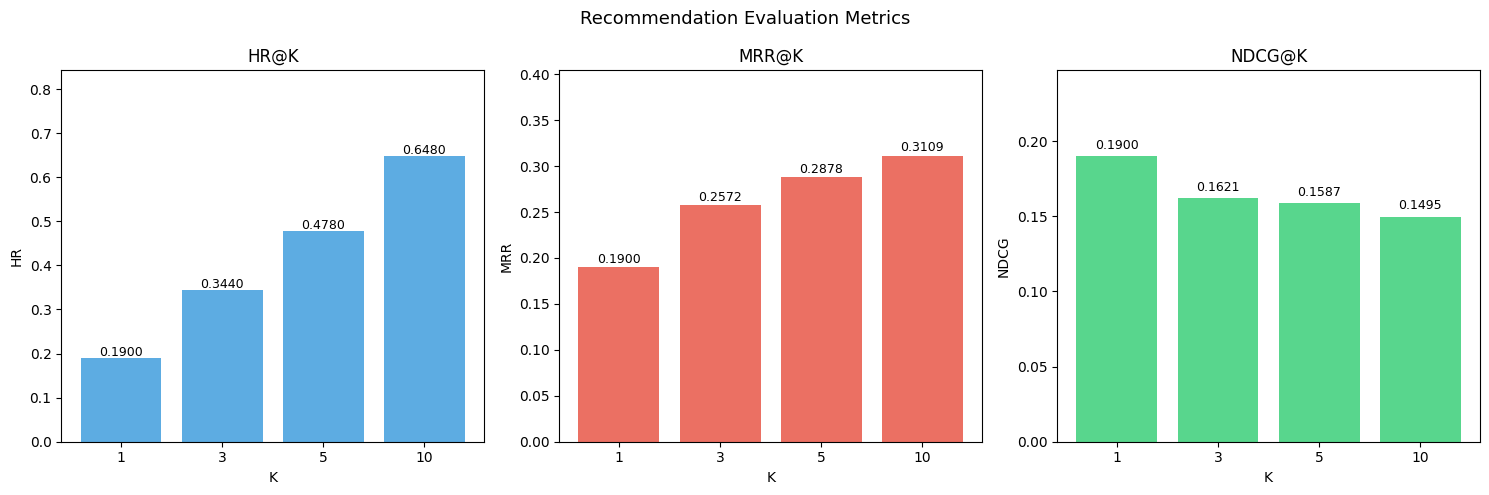

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric_names = ["HR", "MRR", "NDCG"]
colors = ["#3498db", "#e74c3c", "#2ecc71"]

for ax, name, color in zip(axes, metric_names, colors):
    values = [ranking_metrics[k][name] for k in K_VALUES]
    ax.bar([str(k) for k in K_VALUES], values, color=color, alpha=0.8)
    ax.set_title(f"{name}@K")
    ax.set_xlabel("K")
    ax.set_ylabel(name)
    ax.set_ylim(0, max(values) * 1.3 if max(values) > 0 else 1.0)
    for i, v in enumerate(values):
        ax.text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("Recommendation Evaluation Metrics", fontsize=13)
plt.tight_layout()
plt.show()

## 13. Extended Metrics (Coverage, Diversity, Novelty)

In [20]:
# Coverage
all_recommended = set()
for res in results:
    all_recommended.update(res["top_k_recs"][:MAX_K])
coverage = len(all_recommended) / len(movie_titles_set)
print(f"Coverage@{MAX_K}: {coverage:.4f} ({len(all_recommended)}/{len(movie_titles_set)} unique movies)")

def intra_list_diversity(ranked_list):
    if len(ranked_list) < 2:
        return 0.0
    genre_sets = []
    for movie in ranked_list:
        genres = adj.get(movie, {}).get("hasGenre", set())
        genre_sets.append(genres)
    distances = []
    for i in range(len(genre_sets)):
        for j in range(i + 1, len(genre_sets)):
            union = genre_sets[i] | genre_sets[j]
            inter = genre_sets[i] & genre_sets[j]
            distances.append(1.0 - len(inter) / len(union) if union else 1.0)
    return np.mean(distances) if distances else 0.0

diversities = [intra_list_diversity(res["top_k_recs"][:MAX_K]) for res in results]
avg_diversity = np.mean(diversities)
print(f"Avg Intra-List Diversity@{MAX_K}: {avg_diversity:.4f}")

# Novelty
item_popularity = {}
for movie in movie_titles_set:
    item_popularity[movie] = len(adj.get(movie, {}).get("rev_likes", set()))
max_popularity = max(item_popularity.values()) if item_popularity else 1

def novelty_score(ranked_list):
    if not ranked_list:
        return 0.0
    return np.mean([1.0 - item_popularity.get(m, 0) / max(max_popularity, 1) for m in ranked_list])

novelties = [novelty_score(res["top_k_recs"][:MAX_K]) for res in results]
avg_novelty = np.mean(novelties)
print(f"Avg Novelty@{MAX_K}: {avg_novelty:.4f}")

# Pattern distribution
pattern_counter = Counter()
for res in results:
    for pt in res.get("pattern_types", []):
        pattern_counter[pt] += 1
total_pats = sum(pattern_counter.values())
print(f"\nRecommendation Pattern Distribution:")
for pat, cnt in pattern_counter.most_common():
    print(f"  {pat}: {cnt} ({cnt/total_pats*100:.1f}%)")


try:
    print_path_diversity_report(results, k=MAX_K, label=f"Path-balanced λ={LAMBDA_PATH_BALANCE}")
except NameError:
    summary = path_diversity_summary(results, k=MAX_K)
    print("Dominant path type:", summary["dominant_type"])
    print("Dominant path ratio:", round(summary["dominant_ratio"], 4))
    print("Path entropy:", round(summary["entropy"], 4))

Coverage@10: 0.1226 (88/718 unique movies)
Avg Intra-List Diversity@10: 0.8038
Avg Novelty@10: 0.2387

Recommendation Pattern Distribution:
  director: 4333 (43.3%)
  cast: 2967 (29.7%)
  genre: 1449 (14.5%)
  writer: 1249 (12.5%)
  cf: 2 (0.0%)

──────────────────────────────────────────────────
Path-Type Diversity — Path-balanced λ=0.0 @ K=10
──────────────────────────────────────────────────
  Total explanations : 10000
  Dominant type      : director
  Dominant ratio     : 0.4333
  Path entropy       : 1.2643

  Distribution:
    director       4333 ( 43.3%)
    cast           2967 ( 29.7%)
    genre          1449 ( 14.5%)
    writer         1249 ( 12.5%)
    cf                2 (  0.0%)


## 14. Fairness Metrics: Per-Gender Breakdown

In [21]:
user_gender_map = build_user_gender_map(users_sub)
n_m = sum(1 for g in user_gender_map.values() if g == "M")
n_f = sum(1 for g in user_gender_map.values() if g == "F")
print(f"Gender map: {n_m} Male, {n_f} Female users")

group_metrics = compute_group_metrics(results, user_gender_map, K_VALUES)

print(f"\n{'K':>4} | {'HR_M':>7} | {'HR_F':>7} | {'MRR_M':>7} | {'MRR_F':>7} | {'NDCG_M':>8} | {'NDCG_F':>8}")
print("-" * 65)
for k in K_VALUES:
    gm = group_metrics["M"][k]
    gf = group_metrics["F"][k]
    print(f"{k:>4} | {gm['HR']:>7.4f} | {gf['HR']:>7.4f} | "
          f"{gm['MRR']:>7.4f} | {gf['MRR']:>7.4f} | "
          f"{gm['NDCG']:>8.4f} | {gf['NDCG']:>8.4f}")

Gender map: 500 Male, 500 Female users

   K |    HR_M |    HR_F |   MRR_M |   MRR_F |   NDCG_M |   NDCG_F
-----------------------------------------------------------------
   1 |  0.2200 |  0.1600 |  0.2200 |  0.1600 |   0.2200 |   0.1600
   3 |  0.3920 |  0.2960 |  0.2950 |  0.2193 |   0.1872 |   0.1369
   5 |  0.5480 |  0.4080 |  0.3303 |  0.2452 |   0.1861 |   0.1312
  10 |  0.7300 |  0.5660 |  0.3559 |  0.2660 |   0.1806 |   0.1183


In [22]:
users_with_recs = sum(1 for r in results if len(r['top_k_recs']) > 0)
users_no_recs   = sum(1 for r in results if len(r['top_k_recs']) == 0)
print(f'Coverage rate:    {users_with_recs}/{len(results)} users '
      f'({users_with_recs/len(results):.1%}) received recommendations')
print(f'No-rec users:     {users_no_recs} '
      f'({users_no_recs/len(results):.1%}) got empty lists')

# Per-gender coverage
for g in ('M', 'F'):
    g_results = [r for r in results if user_gender_map.get(r['user']) == g]
    g_covered = sum(1 for r in g_results if len(r['top_k_recs']) > 0)
    if g_results:
        print(f'  {g}: {g_covered}/{len(g_results)} '
              f'({g_covered/len(g_results):.1%})')

Coverage rate:    1000/1000 users (100.0%) received recommendations
No-rec users:     0 (0.0%) got empty lists
  M: 500/500 (100.0%)
  F: 500/500 (100.0%)


## 15. ILAP Fairness Metrics

In [23]:
ilap = compute_all_ilap_metrics(results, user_gender_map, k=10, disadv="F", adv="M")
print_ilap_report(ilap, k=10, label="GPT-2 Path Model")


──────────────────────────────────────────────────
ILAP Fairness Metrics — GPT-2 Path Model @ K=10
──────────────────────────────────────────────────
  Differential Fairness ε               1.0420  (lower = fairer)
  Value Unfairness                      0.0287  (≈0 = fair)
  Absolute Unfairness                   0.0243  (≈0 = fair)
  Underestimation Unfairness            0.0198  (≈0 = fair)
  Overestimation Unfairness             0.0089  (≈0 = fair)
  NonParity Unfairness                  0.0169  (≈0 = fair)
  KS Statistic                          0.1900  (p=0.000)
  Generalized Cross Entropy            -0.0080  (lower = fairer)


## 18. Comprehensive Report

In [24]:
K_R = 10
cf_score, _ = counterfactual_fairness_score(results, user_gender_map, adj, K_R)
dp = demographic_parity(results, user_gender_map, K_R)
hr_m = group_metrics["M"][K_R]["HR"]
hr_f = group_metrics["F"][K_R]["HR"]
hr_gap = abs(hr_m - hr_f)

print("=" * 60)
print("GPT-2 PATH MODEL - COMPREHENSIVE REPORT")

print("\n-- Accuracy --")
for k in K_VALUES:
    m = ranking_metrics[k]
    print(f"  HR@{k}={m['HR']:.4f}  MRR@{k}={m['MRR']:.4f}  NDCG@{k}={m['NDCG']:.4f}")

print(f"\n-- Extended --")
print(f"  Coverage@{MAX_K}:  {coverage:.4f}")
print(f"  Diversity@{MAX_K}: {avg_diversity:.4f}")
print(f"  Novelty@{MAX_K}:   {avg_novelty:.4f}")

print("\n-- ILAP Fairness --")
for key, val in ilap.items():
    if key != "KS_pval":
        print(f"  {key:<8} {val:.4f}")

print("\n-- Group-level Fairness Summary --")
print(f"  HR_M@{K_R}:                 {hr_m:.4f}")
print(f"  HR_F@{K_R}:                 {hr_f:.4f}")
print(f"  HR Gap@{K_R}:               {hr_gap:.4f}")
print(f"  Demographic Parity@{K_R}:    {dp:.4f}")
print(f"  Counterfactual Fairness@{K_R}: {cf_score:.4f}")

print("\n-- Pattern Distribution --")
for pat, cnt in pattern_counter.most_common():
    print(f"  {pat}: {cnt} ({cnt/total_pats*100:.1f}%)")

print("=" * 60)

GPT-2 PATH MODEL - COMPREHENSIVE REPORT

-- Accuracy --
  HR@1=0.1900  MRR@1=0.1900  NDCG@1=0.1900
  HR@3=0.3440  MRR@3=0.2572  NDCG@3=0.1621
  HR@5=0.4780  MRR@5=0.2878  NDCG@5=0.1587
  HR@10=0.6480  MRR@10=0.3109  NDCG@10=0.1495

-- Extended --
  Coverage@10:  0.1226
  Diversity@10: 0.8038
  Novelty@10:   0.2387

-- ILAP Fairness --
  DF       1.0420
  VU       0.0287
  AU       0.0243
  UU       0.0198
  OU       0.0089
  NU       0.0169
  KS       0.1900
  GCE      -0.0080

-- Group-level Fairness Summary --
  HR_M@10:                 0.7300
  HR_F@10:                 0.5660
  HR Gap@10:               0.1640
  Demographic Parity@10:    0.6136
  Counterfactual Fairness@10: 0.3738

-- Pattern Distribution --
  director: 4333 (43.3%)
  cast: 2967 (29.7%)
  genre: 1449 (14.5%)
  writer: 1249 (12.5%)
  cf: 2 (0.0%)


## 19. Multi-Run Statistical Validation

In [25]:
# import importlib
# import scripts.multi_run as multi_run
# importlib.reload(multi_run)
#
# SEEDS = [42, 123, 456]
#
# # Multi-run for our main model (demographic-blind GPT-2)
# our_runs = multi_run.run(
#     adj, all_users, test_set_dict, movie_titles_set,
#     user_gender_map, BASE_RELS, device,
#     paths_per_user=100, k_values=K_VALUES, seeds=SEEDS,
# )

In [26]:
# multi_run.report(our_runs, k_values=K_VALUES)

## 20. GPT-2 + Gender Baseline (Optional)

In [27]:
RUN_GENDER_BASELINE = True

GENDER_BASELINE_PATHS_PER_USER = 100
GENDER_BASELINE_WEIGHT = 0.20
GENDER_BASELINE_EPOCHS = 10
GENDER_BASELINE_LAMBDA_PATH_BALANCE = LAMBDA_PATH_BALANCE
GENDER_BASELINE_FREE_REPEATS = PATH_BALANCE_FREE_REPEATS
GENDER_BASELINE_MAX_PATHS_PER_MOVIE = 4
GENDER_BASELINE_EVAL_BATCH_SIZE = EVAL_BATCH_SIZE

if RUN_GENDER_BASELINE:
    import importlib
    try:
        import scripts.baselines as baselines
    except ModuleNotFoundError:
        import baselines
    importlib.reload(baselines)
    K_VALUES = [1, 3, 5, 10]

    results_gender, model_gender, vocab_g, id2tok_g, PAD_g, BOS_g, EOS_g, UNK_g, MAX_LEN_g = \
        baselines.run_gpt2_gender(
            test_set_dict, adj, all_users, movie_titles_set,
            BASE_RELS, device, k_values=K_VALUES,
            paths_per_user=GENDER_BASELINE_PATHS_PER_USER,
            gender_weight=GENDER_BASELINE_WEIGHT,
            epochs=GENDER_BASELINE_EPOCHS, lr=3e-4, patience=3, seed=42,
            lambda_div=GENDER_BASELINE_LAMBDA_PATH_BALANCE,
            path_balance_free_repeats=GENDER_BASELINE_FREE_REPEATS,
            max_paths_per_movie=MAX_PATHS_PER_MOVIE,
            eval_batch_size=EVAL_BATCH_SIZE,
                )
else:
    results_gender = None
    print("Skipped GPT-2+Gender baseline. Set RUN_GENDER_BASELINE=True to run it.")

GPT-2 + GENDER BASELINE

[1/4] Sampling paths (with gender-aware pattern)...
Pattern distribution:
  genre: 35180 (35.2%)
  director: 11591 (11.6%)
  cf: 19881 (19.9%)
  cast: 7162 (7.2%)
  writer: 6119 (6.1%)
  gender: 20067 (20.1%)
Total paths before dedupe: 100000
After dedupe: 99232

[2/4] Building vocabulary and dataset...
Vocab size: 2783
MAX_LEN: 9
Train paths: 89308, Val paths: 9924
Train batches: 1396, Val batches: 156

[3/4] Training GPT-2 + Gender model...
Model params: 2,315,904


Epoch 1/10: 100%|██████████| 1396/1396 [00:33<00:00, 41.72it/s, loss=2.9413, lr=2.93e-04]


  Epoch 1 val_loss: 3.0209


Epoch 2/10: 100%|██████████| 1396/1396 [00:33<00:00, 41.51it/s, loss=2.8023, lr=2.72e-04]


  Epoch 2 val_loss: 2.7995


...

  Epoch 9 val_loss: 2.6148


Epoch 10/10: 100%|██████████| 1396/1396 [00:33<00:00, 41.47it/s, loss=2.5733, lr=1.00e-05]


  Epoch 10 val_loss: 2.6137
Restored best model (val_loss: 2.6137)

[4/4] Evaluating...


Evaluating: 100%|██████████| 1000/1000 [49:52<00:00,  2.99s/it]


──────────────────────────────────────────────────
  GPT-2 + Gender Baseline
──────────────────────────────────────────────────
     K |     HR@K |    MRR@K |   NDCG@K
  ----------------------------------------
     1 |   0.1900 |   0.1900 |   0.1900
     3 |   0.3460 |   0.2582 |   0.1641
     5 |   0.4850 |   0.2893 |   0.1593
    10 |   0.6490 |   0.3113 |   0.1502



In [28]:
from collections import Counter

if results_gender is not None:
    print(Counter(results_gender[0].keys()))

    gender_pattern_counter = Counter()
    for r in results_gender:
        gender_pattern_counter.update(r.get("pattern_types", []))

    print("Pattern types in GPT-2+Gender:")
    print(gender_pattern_counter)
else:
    print("Skipped because results_gender is None.")

Counter({'user': 1, 'ground_truths': 1, 'top_k_recs': 1, 'pattern_types': 1, 'paths': 1, 'num_gt': 1})
Pattern types in GPT-2+Gender:
Counter({'director': 4385, 'cast': 1797, 'writer': 1491, 'genre': 1377, 'gender': 950})


In [29]:
from metrics import (
    compute_group_metrics, compute_all_ilap_metrics, print_ilap_report,
    demographic_parity,
    counterfactual_fairness_score,
)
user_gender_map = build_user_gender_map(users_sub)

if results_gender is not None:
    group_metrics_g1 = compute_group_metrics(results_gender, user_gender_map, K_VALUES)

    print(f"{'K':>4} | {'HR_M':>7} | {'HR_F':>7} | {'MRR_M':>7} | {'MRR_F':>7} | {'NDCG_M':>8} | {'NDCG_F':>8}")
    print("-" * 65)
    for k in K_VALUES:
        gm = group_metrics_g1["M"][k]
        gf = group_metrics_g1["F"][k]
        print(f"{k:>4} | {gm['HR']:>7.4f} | {gf['HR']:>7.4f} | "
              f"{gm['MRR']:>7.4f} | {gf['MRR']:>7.4f} | "
              f"{gm['NDCG']:>8.4f} | {gf['NDCG']:>8.4f}")

    ilap_g1   = compute_all_ilap_metrics(results_gender, user_gender_map, k=10)
    cf_g1, _  = counterfactual_fairness_score(results_gender, user_gender_map, adj, 10)
    dp_g1     = demographic_parity(results_gender, user_gender_map, 10)
    hr_gap_g1 = abs(group_metrics_g1["M"][10]["HR"] - group_metrics_g1["F"][10]["HR"])

    print()
    print(f"  HR Gap@10:               {hr_gap_g1:.4f}")
    print(f"  Demographic Parity@10:    {dp_g1:.4f}")
    print(f"  Counterfactual Fairness@10: {cf_g1:.4f}")

    print()
    print_ilap_report(ilap_g1, k=10, label="GPT-2 + Gender")
else:
    print("Skipped GPT-2 + Gender fairness section because results_gender is None.")

   K |    HR_M |    HR_F |   MRR_M |   MRR_F |   NDCG_M |   NDCG_F
-----------------------------------------------------------------
   1 |  0.2220 |  0.1580 |  0.2220 |  0.1580 |   0.2220 |   0.1580
   3 |  0.4020 |  0.2900 |  0.2997 |  0.2167 |   0.1917 |   0.1364
   5 |  0.5560 |  0.4140 |  0.3340 |  0.2447 |   0.1888 |   0.1297
  10 |  0.7400 |  0.5580 |  0.3587 |  0.2639 |   0.1831 |   0.1172

  HR Gap@10:               0.1820
  Demographic Parity@10:    0.6364
  Counterfactual Fairness@10: 0.3708


──────────────────────────────────────────────────
ILAP Fairness Metrics — GPT-2 + Gender @ K=10
──────────────────────────────────────────────────
  Differential Fairness ε               1.0222  (lower = fairer)
  Value Unfairness                      0.0288  (≈0 = fair)
  Absolute Unfairness                   0.0249  (≈0 = fair)
  Underestimation Unfairness            0.0198  (≈0 = fair)
  Overestimation Unfairness             0.0090  (≈0 = fair)
  NonParity Unfairness               

### Multi-Run: GPT-2 + Gender

In [30]:
# import importlib
# import paths as _paths_mod
# import scripts.baselines as _bl
# importlib.reload(_bl)
#
# # Register gender sampler into the same `paths` module that multi_run uses
# _paths_mod._SAMPLERS["gender"] = _bl._sample_gender_cf_path
#
# GENDER_WEIGHTS = {
#     "genre": 0.20, "director": 0.16, "cf": 0.16,
#     "cast": 0.12, "composer": 0.08, "writer": 0.08,
#     "gender": 0.20,
# }
#
# try:
#     gender_runs = multi_run.run(
#         adj, all_users, test_set_dict, movie_titles_set,
#         user_gender_map, BASE_RELS | {"hasGender"}, device,
#         paths_per_user=100, k_values=K_VALUES, seeds=SEEDS,
#         pattern_weights=GENDER_WEIGHTS,
#     )
# finally:
#     _paths_mod._SAMPLERS.pop("gender", None)

In [31]:
# multi_run.report(gender_runs, k_values=K_VALUES)

### Statistical Comparison: GPT-2 (Ours) vs GPT-2 + Gender

In [32]:
# multi_run.compare(our_runs, gender_runs, k=10)

## 21. Fairness Metrics — GPT-2 vs GPT-2 + Gender

In [33]:
if results_gender is not None:
    from metrics import (
        compute_group_metrics, compute_all_ilap_metrics,
        demographic_parity, counterfactual_fairness_score,
    )

    # Group metrics
    group_metrics_gender = compute_group_metrics(results_gender, user_gender_map, K_VALUES)

    # Per-gender HR@K for both models
    def gender_hr(gm, k):
        return gm["M"][k]["HR"], gm["F"][k]["HR"]

    hr_m_ours,   hr_f_ours   = gender_hr(group_metrics,        10)
    hr_m_gender, hr_f_gender = gender_hr(group_metrics_gender, 10)

    # ILAP
    ilap_ours   = compute_all_ilap_metrics(results,        user_gender_map, k=10)
    ilap_gender = compute_all_ilap_metrics(results_gender, user_gender_map, k=10)

    # Scalar fairness metrics
    cf_ours,   _ = counterfactual_fairness_score(results,        user_gender_map, adj, 10)
    cf_gender, _ = counterfactual_fairness_score(results_gender, user_gender_map, adj, 10)

    dp_ours   = demographic_parity(results,        user_gender_map, 10)
    dp_gender = demographic_parity(results_gender, user_gender_map, 10)
else:
    print("Skipped GPT-2 vs GPT-2+Gender fairness comparison because results_gender is None.")

In [34]:
if results_gender is not None:
    k_r = 10
    rm = ranking_metrics[k_r]
    gm = evaluate_ranking(results_gender, k_values=K_VALUES)[k_r]

    rows = [
        ("HR@10",    rm["HR"],    gm["HR"]),
        ("HR_M@10",  hr_m_ours,   hr_m_gender),
        ("HR_F@10",  hr_f_ours,   hr_f_gender),
        ("MRR@10",   rm["MRR"],   gm["MRR"]),
        ("NDCG@10",  rm["NDCG"],  gm["NDCG"]),
        ("", None, None),
        ("DP@10",    dp_ours,     dp_gender),
        ("CF@10",    cf_ours,     cf_gender),
    ]

    sep = "-" * 60
    print(sep)
    print(f"{'Metric':<20}  {'GPT-2 (Ours)':>15}  {'GPT-2+Gender':>15}")
    print(sep)
    for name, v1, v2 in rows:
        if v1 is None:
            print()
            continue
        print(f"{name:<20}  {v1:>15.4f}  {v2:>15.4f}")
    print(sep)
else:
    print("Skipped GPT-2 vs GPT-2+Gender comparison because results_gender is None.")

------------------------------------------------------------
Metric                   GPT-2 (Ours)     GPT-2+Gender
------------------------------------------------------------
HR@10                          0.6480           0.6490
HR_M@10                        0.7300           0.7400
HR_F@10                        0.5660           0.5580
MRR@10                         0.3109           0.3113
NDCG@10                        0.1495           0.1502

DP@10                          0.6136           0.6364
CF@10                          0.3738           0.3708
------------------------------------------------------------


In [35]:
# Per-gender breakdown table for both models
def print_gender_table(gm, label, k_values, gender_map):
    n_m = sum(1 for g in gender_map.values() if g == 'M')
    n_f = sum(1 for g in gender_map.values() if g == 'F')
    print()
    print(label)
    print(f'Gender map: {n_m} Male, {n_f} Female users')
    print()
    col = ' | '
    hdr = (f"{'K':>4}" + col + f"{'HR_M':>7}" + col + f"{'HR_F':>7}" + col
           + f"{'MRR_M':>7}" + col + f"{'MRR_F':>7}" + col
           + f"{'NDCG_M':>8}" + col + f"{'NDCG_F':>8}")
    print(hdr)
    print('-' * len(hdr))
    for k in k_values:
        m = gm['M'][k]
        f_ = gm['F'][k]
        print(
            f"{k:>4}" + col +
            f"{m['HR']:>7.4f}" + col +
            f"{f_['HR']:>7.4f}" + col +
            f"{m['MRR']:>7.4f}" + col +
            f"{f_['MRR']:>7.4f}" + col +
            f"{m['NDCG']:>8.4f}" + col +
            f"{f_['NDCG']:>8.4f}"
        )

print_gender_table(group_metrics,        '=== GPT-2 (Ours) ===',   K_VALUES, user_gender_map)
print_gender_table(group_metrics_gender, '=== GPT-2 + Gender ===', K_VALUES, user_gender_map)


=== GPT-2 (Ours) ===
Gender map: 500 Male, 500 Female users

   K |    HR_M |    HR_F |   MRR_M |   MRR_F |   NDCG_M |   NDCG_F
------------------------------------------------------------------
   1 |  0.2200 |  0.1600 |  0.2200 |  0.1600 |   0.2200 |   0.1600
   3 |  0.3920 |  0.2960 |  0.2950 |  0.2193 |   0.1872 |   0.1369
   5 |  0.5480 |  0.4080 |  0.3303 |  0.2452 |   0.1861 |   0.1312
  10 |  0.7300 |  0.5660 |  0.3559 |  0.2660 |   0.1806 |   0.1183

=== GPT-2 + Gender ===
Gender map: 500 Male, 500 Female users

   K |    HR_M |    HR_F |   MRR_M |   MRR_F |   NDCG_M |   NDCG_F
------------------------------------------------------------------
   1 |  0.2220 |  0.1580 |  0.2220 |  0.1580 |   0.2220 |   0.1580
   3 |  0.4020 |  0.2900 |  0.2997 |  0.2167 |   0.1917 |   0.1364
   5 |  0.5560 |  0.4140 |  0.3340 |  0.2447 |   0.1888 |   0.1297
  10 |  0.7400 |  0.5580 |  0.3587 |  0.2639 |   0.1831 |   0.1172


In [36]:
# ILAP side-by-side
all_keys = sorted(set(ilap_ours) | set(ilap_gender))
sep = "-" * 60
print()
print(sep)
print(f"{'ILAP Metric':<20}  {'GPT-2 (Ours)':>15}  {'GPT-2+Gender':>15}")
print(sep)
for key in all_keys:
    v1 = ilap_ours.get(key, float("nan"))
    v2 = ilap_gender.get(key, float("nan"))
    if isinstance(v1, (int, float)):
        print(f"{key:<20}  {v1:>15.4f}  {v2:>15.4f}")
    else:
        print(f"{key:<20}  {str(v1):>15}  {str(v2):>15}")
print(sep)


------------------------------------------------------------
ILAP Metric              GPT-2 (Ours)     GPT-2+Gender
------------------------------------------------------------
AU                             0.0243           0.0249
DF                             1.0420           1.0222
GCE                           -0.0080          -0.0099
KS                             0.1900           0.1920
KS_pval                        0.0000           0.0000
NU                             0.0169           0.0171
OU                             0.0089           0.0090
UU                             0.0198           0.0198
VU                             0.0287           0.0288
------------------------------------------------------------


## 23. Per-K Fairness Table — Both Models

In [37]:
# Fairness metrics at every K value — both models side by side
print('=' * 75)
print(f'{"Model":<20} {"K":>4} | {"HR_M":>7} {"HR_F":>7} {"Gap":>7} {"DI":>7} {"EO":>7}')
print('-' * 75)
for label, gm in [('GPT-2 (Ours)', group_metrics), ('GPT-2+Gender', group_metrics_gender)]:
    for k in K_VALUES:
        hr_m = gm['M'][k]['HR']
        hr_f = gm['F'][k]['HR']
        gap  = hr_f - hr_m
        denom = max(hr_m, hr_f)
        di   = min(hr_m, hr_f) / denom if denom > 0 else 1.0
        eo   = abs(gap)
        print(f'{label:<20} {k:>4} | {hr_m:>7.4f} {hr_f:>7.4f} {gap:>+7.4f} {di:>7.4f} {eo:>7.4f}')
    print('-' * 75)

Model                   K |    HR_M    HR_F     Gap      DI      EO
---------------------------------------------------------------------------
GPT-2 (Ours)            1 |  0.2200  0.1600 -0.0600  0.7273  0.0600
GPT-2 (Ours)            3 |  0.3920  0.2960 -0.0960  0.7551  0.0960
GPT-2 (Ours)            5 |  0.5480  0.4080 -0.1400  0.7445  0.1400
GPT-2 (Ours)           10 |  0.7300  0.5660 -0.1640  0.7753  0.1640
---------------------------------------------------------------------------
GPT-2+Gender            1 |  0.2220  0.1580 -0.0640  0.7117  0.0640
GPT-2+Gender            3 |  0.4020  0.2900 -0.1120  0.7214  0.1120
GPT-2+Gender            5 |  0.5560  0.4140 -0.1420  0.7446  0.1420
GPT-2+Gender           10 |  0.7400  0.5580 -0.1820  0.7541  0.1820
---------------------------------------------------------------------------


## 24. Path Pattern Distribution by Gender

In [38]:
import importlib
try:
    import scripts.metrics as _m
except ModuleNotFoundError:
    import metrics as _m
importlib.reload(_m)

print('=== GPT-2 / Path-balanced KG model ===')
_m.print_path_diversity_report(results, k=10, label=f'Path-balanced λ={LAMBDA_PATH_BALANCE}')
_m.print_path_fairness_report(results, user_gender_map, adj, label="GPT-2 / PEARLM-style")

if results_gender is not None:
    print('\n=== GPT-2 + Gender ===')
    _m.print_path_fairness_report(results_gender, user_gender_map, adj, label="GPT-2 + Gender")
else:
    print("\nSkipped GPT-2+Gender path fairness report because results_gender is None.")

=== GPT-2 / Path-balanced KG model ===

──────────────────────────────────────────────────
Path-Type Diversity — Path-balanced λ=0.0 @ K=10
──────────────────────────────────────────────────
  Total explanations : 10000
  Dominant type      : director
  Dominant ratio     : 0.4333
  Path entropy       : 1.2643

  Distribution:
    director       4333 ( 43.3%)
    cast           2967 ( 29.7%)
    genre          1449 ( 14.5%)
    writer         1249 ( 12.5%)
    cf                2 (  0.0%)

──────────────────────────────────────────────────
Path Fairness Metrics — GPT-2 / PEARLM-style @ K=10
──────────────────────────────────────────────────

  Path Length by Gender:
    Male   : mean=7.00  std=0.00  n=5000
    Female : mean=7.00  std=0.00  n=5000
    Gap    : 0.00

  Path Type Distribution (explanation pattern):
    Relation                      Male   Female      Gap
    ----------------------------------------------------
    cast                         0.293    0.301   -0.008
    c

## 26. UserCF, SVD-MF, MLP-CF

In [39]:
RUN_TRADITIONAL_BASELINES = True

if RUN_TRADITIONAL_BASELINES:
    import importlib
    try:
        import scripts.traditional_baselines as tb
    except ModuleNotFoundError:
        import traditional_baselines as tb
    importlib.reload(tb)
    K_VALUES = [1, 3, 5, 10]
    MAX_K = max(K_VALUES)

    results_ucf, results_svd, results_mlp = tb.run_all(
        train_interactions, test_set_dict, movies_sub,
        k=MAX_K, seed=42, device=device,
        ucf_neighbors=20,
        svd_factors=50, svd_epochs=20,
        mlp_factors=32, mlp_epochs=20,
    )
    print("Done. UserCF / SVD-MF / MLP-CF results ready.")
else:
    results_ucf = results_svd = results_mlp = None
    print("Skipped traditional baselines. Set RUN_TRADITIONAL_BASELINES=True to run them.")

  UserCF: User-Based Collaborative Filtering


UserCF: 100%|██████████| 1000/1000 [00:01<00:00, 751.83it/s]


  SVD-MF: Matrix Factorization (BPR)
  Epoch 5/20  BPR loss: 0.6926
  Epoch 10/20  BPR loss: 0.6118
  Epoch 15/20  BPR loss: 0.5238
  Epoch 20/20  BPR loss: 0.4589


SVD-MF: 100%|██████████| 1000/1000 [00:00<00:00, 24056.25it/s]


  MLP-CF: Neural Collaborative Filtering
  Epoch 5/20  BCE loss: 0.4376
  Epoch 10/20  BCE loss: 0.3914
  Epoch 15/20  BCE loss: 0.3760
  Epoch 20/20  BCE loss: 0.3626


MLP-CF: 100%|██████████| 1000/1000 [00:00<00:00, 1639.16it/s]

Done. UserCF / SVD-MF / MLP-CF results ready.


In [40]:
if RUN_TRADITIONAL_BASELINES:
    all_models = {
        "GPT-2" : results,
    }
    if results_gender is not None:
        all_models["GPT-2 + Gender"] = results_gender

    all_models.update({
        "UserCF": results_ucf,
        "SVD-MF": results_svd,
        "MLP-CF": results_mlp,
    })

    comparison_summary = tb.compare_all(all_models, user_gender_map, adj=adj, k_values=K_VALUES)
else:
    print("Skipped baseline comparison table because RUN_TRADITIONAL_BASELINES=False.")

  MODEL COMPARISON — Accuracy & Fairness @ K=10

Model                HR@10  MRR@10  NDCG@10    HR_M    HR_F     Gap      DI      EO      DP      CF
----------------------------------------------------------------------------------------------------
GPT-2               0.6480  0.3109   0.1495  0.7300  0.5660 -0.1640 
GPT-2 + Gender      0.6490  0.3113   0.1502  0.7400  0.5580 -0.1820 
UserCF              0.6990  0.3063   0.1552  0.7740  0.6240 -0.1500 
SVD-MF              0.6720  0.3304   0.1657  0.7540  0.5900 -0.1640 
MLP-CF              0.6720  0.3083   0.1550  0.7420  0.6020 -0.1400 

Model               HR@ 1  HR@ 3  HR@ 5  HR@10  NDCG@ 1  NDCG@ 3  NDCG@ 5  NDCG@10
----------------------------------------------------------------------------------
GPT-2               0.1900  0.3440  0.4780  0.6480   0.1900   0.1621   0.1587   0.1495
GPT-2 + Gender      0.1900  0.3460  0.4850  0.6490   0.1900   0.1641   0.1593   0.1502
UserCF              0.1630  0.3750  0.5040  0.6990   0.1630   0.

In [41]:
import random

sample_users = list(test_set_dict.keys())[:1]

for user_node in sample_users:
    uid = int(user_node.replace("User_", ""))
    gender = user_info.get(uid, {}).get("gender", "?")

    print(f"\n{'='*65}")
    print(f"  {user_node}  (gender={gender})")
    print(f"{'='*65}")

    #Train likes
    train_likes = sorted(adj[user_node].get("likes", set()))
    print(f"\n  TRAIN liked movies ({len(train_likes)}):")
    for m in train_likes[:8]:
        print(f"    • {m}")
    if len(train_likes) > 8:
        print(f"    ... (+{len(train_likes)-8} more)")

    #Test ground truths
    gt = test_set_dict.get(user_node, [])
    print(f"\n  TEST ground truths ({len(gt)}):")
    for m in gt:
        print(f"       {m}")

    #Training paths
    user_paths = [p for p in paths if p[0] == user_node]
    sample_paths = random.sample(user_paths, min(5, len(user_paths)))
    print(f"\n  SAMPLE TRAIN PATHS ({len(user_paths)} total, showing 5):")
    for p in sample_paths:
        rel = p[3] if len(p) > 3 else "?"
        entity = p[4] if len(p) > 4 else "?"
        movie_b = p[6] if len(p) > 6 else "?"
        print(f"    [{rel}]  {p[2]}  →  {entity}  →  {movie_b}")

    #Top 10 recommendations
    user_result = next((r for r in results if r['user'] == user_node), None)
    if user_result:
        recs = user_result['top_k_recs']
        pats = user_result['pattern_types']
        print(f"\n  TOP-10 RECOMMENDATIONS:")
        for rank, (movie, pat) in enumerate(zip(recs, pats), 1):
            hit = "HIT" if movie in set(gt) else ""
            print(f"    {rank:>2}. [{pat:>15}]  {movie}  {hit}")

    print()


  User_10  (gender=F)

  TRAIN liked movies (156):
    • 20,000 Leagues Under the Sea (1954)
    • Ace Ventura: Pet Detective (1994)
    • Adventures in Babysitting (1987)
    • Airplane! (1980)
    • Aladdin (1992)
    • Alice in Wonderland (1951)
    • Alien (1979)
    • Alien: Resurrection (1997)
    ... (+148 more)

  TEST ground truths (39):
       Star Wars: Episode IV - A New Hope (1977)
       Star Wars: Episode V - The Empire Strikes Back (1980)
       Contact (1997)
       E.T. the Extra-Terrestrial (1982)
       Star Trek IV: The Voyage Home (1986)
       Galaxy Quest (1999)
       Twelve Monkeys (1995)
       Aliens (1986)
       Time Bandits (1981)
       Cocoon (1985)
       Superman (1978)
       Escape from New York (1981)
       Soylent Green (1973)
       Jumanji (1995)
       Big (1988)
       Hook (1991)
       Willow (1988)
       Dune (1984)
       Tron (1982)
       Roman Holiday (1953)
       Monty Python and the Holy Grail (1974)
       As Good As It Gets (199

In [42]:
movie_id_to_label = dict(zip(movies_sub['movieId'], movies_sub['title']))

In [43]:
all_ok = True
for user_node, ground_truths in list(test_set_dict.items())[:10]:
    all_liked = set(
        movie_id_to_label[int(row.movieId)]
        for row in positive_interactions[
            positive_interactions['userId'] == int(user_node.replace('User_',''))
        ].itertuples()
        if int(row.movieId) in movie_id_to_label
    )

    bad = [m for m in ground_truths if m not in all_liked]
    status = "OK" if not bad else f"NOK: {bad}"
    print(f"{user_node}: {len(ground_truths)} GT film — {status}")
    if bad:
        all_ok = False

print()

User_10: 39 GT film — OK
User_18: 24 GT film — OK
User_26: 12 GT film — OK
User_33: 25 GT film — OK
User_34: 16 GT film — OK
User_45: 12 GT film — OK
User_48: 21 GT film — OK
User_53: 55 GT film — OK
User_58: 43 GT film — OK
User_59: 14 GT film — OK

